# Logistic Regression
**Recitation by Dr. Stephanie Milani**

_11:00, 15:30 Office Hours at CDS Room 506 (For any follow-up questions)_

In these lab sessions, we will be using Jupyter notebooks running on Google Colab, which has most Python libraries installed.

Please find the folder together with the accompanying files here: https://drive.google.com/drive/folders/1GzlOJJgf9GgsDuz4uqIoCX13y3uBZRsO?usp=share_link and make a copy of the folder in your own Google Drive.

Please open the IPython notebook in the folder. This notebook aims to introduce logistic regression models using PyTorch and pandas libraries in the weather forecasting application.

## Weather prediction

Previous recitation introduced the elements of a traditional machine learning pipeline through a weather forecasting application in Python. The data set of weather recordings from New York City is collected from [Open-Meteo](https://open-meteo.com/) between 2016 to 2022 in the column-separated file 'NYC_Weather_2016_2022.csv'.

We will start by allowing our application access to our local Google drives so files can be loaded into our Python programs.

Mounted at /content/drive


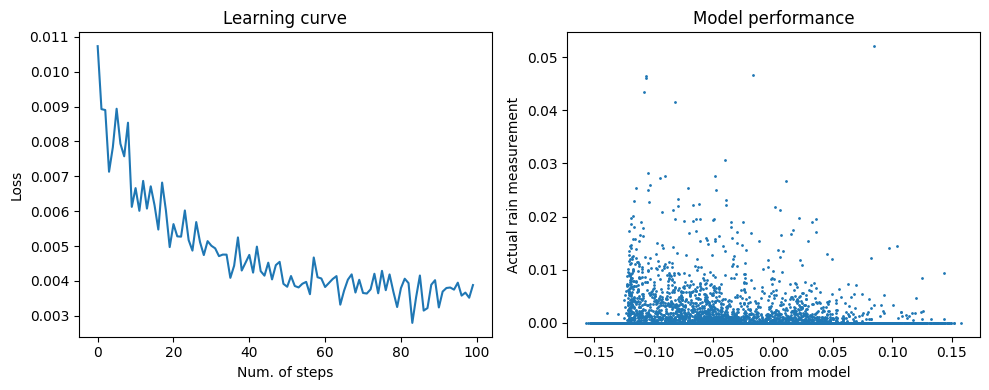

In [1]:
from google.colab import drive
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

drive.mount('/content/drive')

### update with your own path like last time!!! ####
### we are using the same data, so you can directly copy and paste from the previous notebook ###
dataset_path = '/content/drive/MyDrive/Machine learning 473/recitation/NYC_Weather_2016_2022.csv'

class WeatherDataset(Dataset):
    def __init__(self, train_in, train_out):
        self.x_data = train_in  # [n_samples, n_features]
        self.y_data = train_out # [n_samples, 1]
        self.n_samples = train_in.shape[0]

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.n_samples


class LinearRegression(torch.nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear = torch.nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)


def process_csv(filename, target_col_idx=2, train_ratio=0.8, seed=0):
    df = pd.read_csv(filename)
    df = df.dropna()

    num_df = df.select_dtypes(include=['number'])
    full = torch.tensor(num_df.values, dtype=torch.float32)
    full = torch.nn.functional.normalize(full)

    # train/test split
    n = full.shape[0]
    n_train = int(train_ratio * n)
    n_test = n - n_train
    train_set, test_set = random_split(
        full, [n_train, n_test],
        generator=torch.Generator().manual_seed(seed)
    )

    # stack into tensors
    traindata = torch.stack([t for t in train_set])
    testdata  = torch.stack([t for t in test_set])

    # build inputs by excluding the target column (assumed at target_col_idx)
    # equivalent to: X = all columns except target; y = target column
    train_in = torch.cat([traindata[:, :target_col_idx], traindata[:, target_col_idx+1:]], dim=1)
    test_in  = torch.cat([testdata[:,  :target_col_idx], testdata[:,  target_col_idx+1:]],  dim=1)
    train_out = traindata[:, target_col_idx].unsqueeze(1)
    test_out  = testdata[:,  target_col_idx].unsqueeze(1)

    return train_in, train_out, test_in, test_out

def train(model, loss_fn, optimizer, training_data, steps, batch_size):
    loader = DataLoader(training_data, batch_size=batch_size, shuffle=True, drop_last=False)
    losses = []
    step = 0
    model.train()
    while step < steps:
        for inputs, targets in loader:
            optimizer.zero_grad()
            outputs = model(inputs)                 # inputs: [B, D], outputs: [B, 1]
            l = loss_fn(outputs, targets)
            l.backward()
            optimizer.step()
            losses.append(float(l.detach()))
            step += 1
            if step >= steps:
                break
    return losses

# === Run ===
train_in, train_out, test_in, test_out = process_csv(dataset_path)
training_data = WeatherDataset(train_in, train_out)

# hyperparameters
learning_rate = 0.01
steps = 100
batch_size = 256

# set up model
model = LinearRegression(input_size=train_in.shape[1] , output_size=1)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# train model
losses = train(model, loss_fn, optimizer, training_data, steps, batch_size)

# === Plots ===
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.plot(range(len(losses)), losses)
plt.title('Learning curve')
plt.xlabel('Num. of steps')
plt.ylabel('Loss')

model.eval()
with torch.no_grad():
    preds = model(test_in).squeeze(1).cpu().numpy()
    targets = test_out.squeeze(1).cpu().numpy()

plt.subplot(1, 2, 2)
plt.title('Model performance')
plt.xlabel('Prediction from model')
plt.ylabel('Actual rain measurement')
plt.plot(preds, targets, 'o', markersize=1.0)

plt.tight_layout()
plt.show()

## Exercise 1

Using the provided example, plot 9 different plots for the model learning curves by ranging the batchsize in range $\{32, 64, 128\}$, and the learning rate in range $\{0.005, 0.01, 0.05\}$. At each time, observe and comment on how the change of hyperparameter affects different properties of the learning curve (e.g. the shape, the smoothness or sharpness).

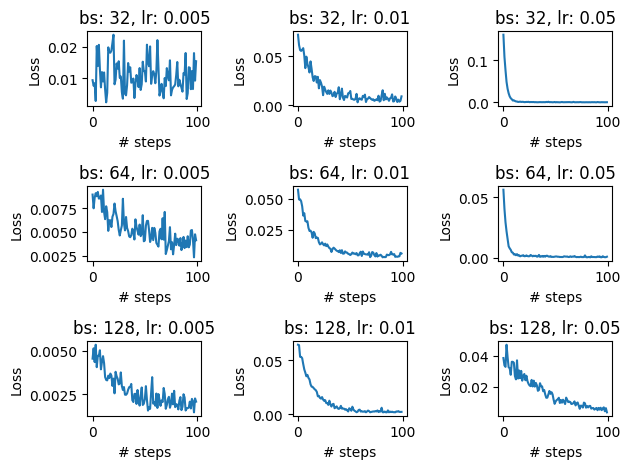

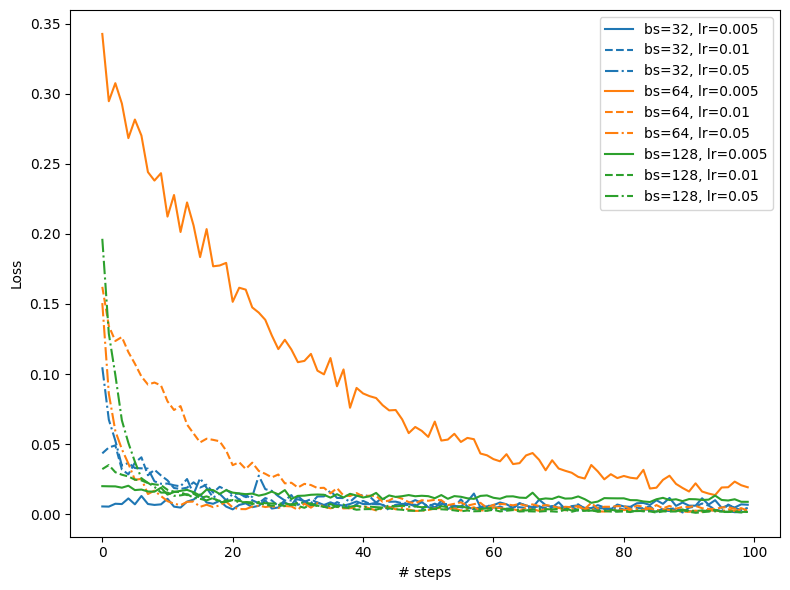

In [2]:
## Solution ##
fig, axs = plt.subplots(3, 3)

def experiment1():
  loss = torch.nn.MSELoss()
  steps = 100

  for i, batch_size in enumerate([32, 64, 128]):
    for j, learning_rate in enumerate([0.005, 0.01, 0.05]):
      model = LinearRegression(input_size=train_in.shape[1], output_size=1)
      optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
      losses = train(model, loss_fn, optimizer, training_data, steps, batch_size)

      axs[i][j].plot(range(steps), losses)
      axs[i][j].set_title('bs: {}, lr: {}'.format(batch_size, learning_rate))
      axs[i][j].set_xlabel('# steps')
      axs[i][j].set_ylabel('Loss')


  plt.tight_layout()
  plt.show()

experiment1()

def alt_experiment1():
    loss_fn = torch.nn.MSELoss()
    steps = 100
    plt.figure(figsize=(8, 6))

    batch_colors = {32: "tab:blue", 64: "tab:orange", 128: "tab:green"}
    lr_styles = {0.005: "-", 0.01: "--", 0.05: "-."}

    for batch_size in [32, 64, 128]:
        for learning_rate in [0.005, 0.01, 0.05]:
            model = LinearRegression(input_size=train_in.shape[1], output_size=1)
            optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
            losses = train(model, loss_fn, optimizer, training_data, steps, batch_size)

            label = f"bs={batch_size}, lr={learning_rate}"
            plt.plot(
                range(steps),
                losses,
                label=label,
                color=batch_colors[batch_size],
                linestyle=lr_styles[learning_rate]
            )

    plt.xlabel("# steps")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

alt_experiment1()

## Exercise 2

Implement a Python application for rain prediction in New York City using the data set and provided functions for data processing and linear regression which uses the mean absolute error as the loss function. You may use any PyTorch functions.

Mean absolute error is defined as:

$$
 MAE(x, y) = \frac{1}{n} \sum_{i=1}^n |y_i - x_i|
$$

Plot the prediction vs. actual rain measurement plots for the different models.

**Note**: Each model might have different hypermaparameters optimal for their convergence. You can use the variables $learning_rate$ and $steps$ which are inputs to the training function to tune the optimal training hyperparameters of your regression model.

The min. squared error in training is:  0.008217893540859222


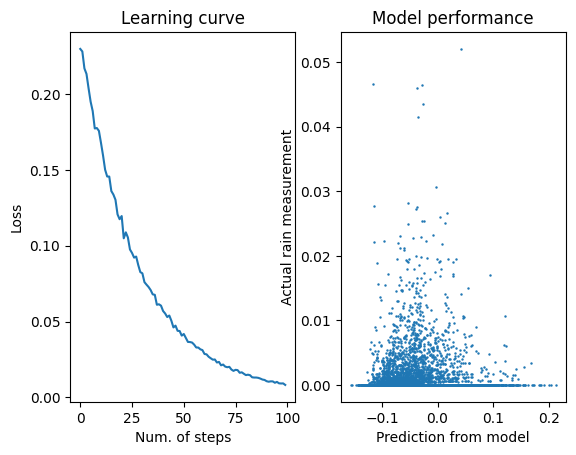

In [3]:
## Solution ##
### Q: Why does a line plot over time not make sense here? ###

def experiment2():
  train_in, train_out, test_in, test_out = process_csv(dataset_path)
  trainingData = WeatherDataset(train_in, train_out)

  learning_rate = 0.005
  steps = 100
  batch_size = 256

  model = LinearRegression(input_size=train_in.shape[1], output_size=1)
  loss = torch.nn.L1Loss()
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  losses = train(model, loss_fn, optimizer, training_data, steps, batch_size)
  print("The min. squared error in training is: ", min(losses))

  plt.subplot(1, 2, 1)
  plt.plot(range(steps), losses)
  plt.title('Learning curve')
  plt.xlabel('Num. of steps')
  plt.ylabel('Loss')

  with torch.no_grad():
    predictions = model(test_in)
    plt.subplot(1, 2, 2)
    plt.xlabel('Prediction from model')
    plt.ylabel('Actual rain measurement')
    plt.title('Model performance')
    plt.plot(predictions, test_out, 'o', markersize=.75)

experiment2()


## Takes from our initial experiments -- what's weird? What doesn't make sense? Anything surprising?

1. ???


How could we address issues in the pipeline?

Let's think about it. Theoretically, the range of values of the input $x$ and output $y$ of a linear regression model

$$
  y = A*x + b
$$

is the $\mathbb{R}$.

In our application, the rain measurement values are in the range $[0, 1]$ since we have normalized them. In order to inform the model of this restriction, we can extend the model equation with an additional layer using an **activation function**.

## Logistic function

A typical function that could restrict the range of values produced by a linear projection module is the **logistic** function which takes a range of real values and transforms them into the range of values in $[0, 1]$.

$$
  \sigma (x) = \frac{e^x}{1 + e^x}
$$


(0.0, 1.0)

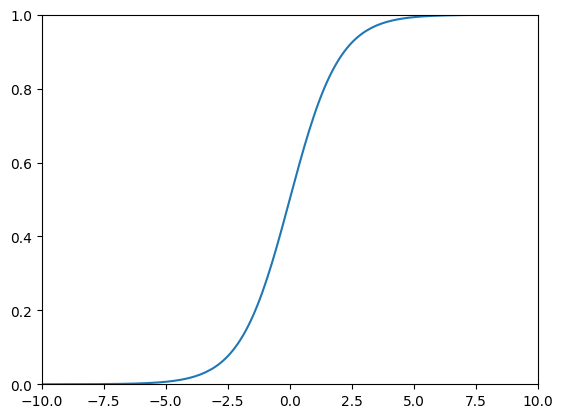

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

xi = np.arange(-10, 10, 0.1)
y = [ math.exp(x) / (1 + math.exp(x)) for x in xi]

plt.plot(xi, y)
plt.xlim(-10, 10)
plt.ylim(0, 1)


In [ ]:
class LogisticRegression(torch.nn.Module):
    def __init__(self, input_size, output_size):
        super(LogisticRegression, self).__init__()
        self.linear = torch.nn.Linear(input_size, output_size, bias=True)
        self.act = torch.nn.Sigmoid()

    def forward(self, x):
        y = self.linear(x)
        z = self.act(y)
        return z

We can try to test how the output range will now change.

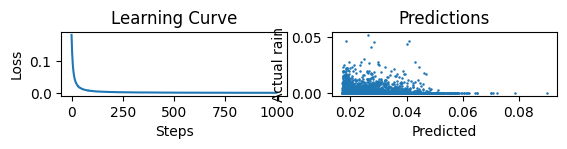

In [ ]:
def experiment3():
  train_in, train_out, test_in, test_out = process_csv(dataset_path)
  trainingData = WeatherDataset(train_in, train_out)
  learning_rate = 0.3
  steps = 1000
  batch_size = 256

  model = LogisticRegression(input_size=train_in.shape[1], output_size=1)
  optimizer = torch.optim.SGD(model.parameters(), lr=0.3)
  loss_fn = torch.nn.MSELoss()

  losses = train(model, loss_fn, optimizer, training_data, steps, batch_size)

  # Learning curve
  plt.subplot(5, 2, 1)
  plt.plot(losses)
  plt.title(f"Learning Curve")
  plt.xlabel("Steps")
  plt.ylabel("Loss")

  # Predictions
  with torch.no_grad():
      preds = model(test_in)

  plt.subplot(5, 2, 2)
  plt.plot(preds.numpy(), test_out.numpy(), "o", markersize=0.8)
  plt.title("Predictions")
  plt.xlabel("Predicted")
  plt.ylabel("Actual rain")
  return preds

predictions = experiment3()

Note that our model has only 8 input features, thus, an 8x1 $A$ matrix for predicting the linear projection $y = A*x $ weight of each feature. If we wanted to understand how these features are weighted at each prediction, we could try to visualize their values.

In [ ]:
df = pd.read_csv(dataset_path)
print(list(df.columns[1:3]) + list(df.columns[4::]))
print(model.linear.weight)

['temperature_2m (°C)', 'precipitation (mm)', 'cloudcover (%)', 'cloudcover_low (%)', 'cloudcover_mid (%)', 'cloudcover_high (%)', 'windspeed_10m (km/h)', 'winddirection_10m (°)']
Parameter containing:
tensor([[-0.2740,  0.1689, -0.0589,  0.0775,  0.1749, -0.1830, -0.0534,  0.2062]],
       requires_grad=True)


## Classification and Prediction Accuracy

A linear model with only 8 parameters may not be able to accurately model a highly complex hypothesis using an imbalanced and sparse data set. In order to ease the complexity of the task we can reduce the complexity to a **classification** task. In this case, we can still try to estimate whether or not it will rain at a given moment using our logistic model.

Text(0, 0.5, 'Loss')

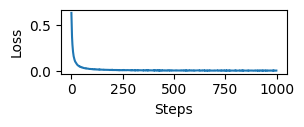

In [ ]:
train_in, train_out, test_in, test_out = process_csv(dataset_path)
train_out = (train_out > 0).float() # 1 if rain > 0, else 0
test_out = (test_out > 0).float()
trainingData = WeatherDataset(train_in, train_out)
learning_rate = 0.3
steps = 1000
batch_size = 256

model = LogisticRegression(input_size=train_in.shape[1], output_size=1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.3)
loss_fn = torch.nn.BCELoss()  # use a new loss!

losses = train(model, loss_fn, optimizer, training_data, steps, batch_size)

plt.subplot(5, 2, 1)
plt.plot(losses)
plt.xlabel("Steps")
plt.ylabel("Loss")



**Accuracy** is the percentage of all correctly classified examples in our test set.  

A more refined analysis can be performed using **the confusion matrix**:
$$
C = \begin{bmatrix}
\text{Predict 0, Actual 0} & \text{Predict 0, Actual 1}\\
\text{Predict 1, Actual 0} & \text{Predict 1, Actual 1}
\end{bmatrix}
$$

Notice that the diagonal entries are the examples that are correctly classified.  

The most useful classification metrics are **Precision** and **Recall**. If we define a prediction $C_{ij}$ which belongs to class i for which we estimated the label i, we calculate them as follows.

#### Precision Score
The precision score is the percentage
$$
\text{Precision}_0 = \frac{C_{00}}{C_{00} + C_{01}}
$$

$$
\text{Precision}_1 = \frac{C_{11}}{C_{11} + C_{10}}
$$
which is the percentage of predicted rain possibility that we classify correctly.  

#### Recall Score
The recall score is the percentage
$$
\textrm{Recall}_0 = \frac{C_{00}}{C_{00} + C_{10}}
$$
$$
\textrm{Recall}_1 = \frac{C_{11}}{C_{11} + C_{01}}
$$
which is the percentage of rain possibility that we classify correctly. Note that Precision and Recall are two different quantities.

**Using multiple evaluation metrics helps give a better picture of how well our classifier is doing.**

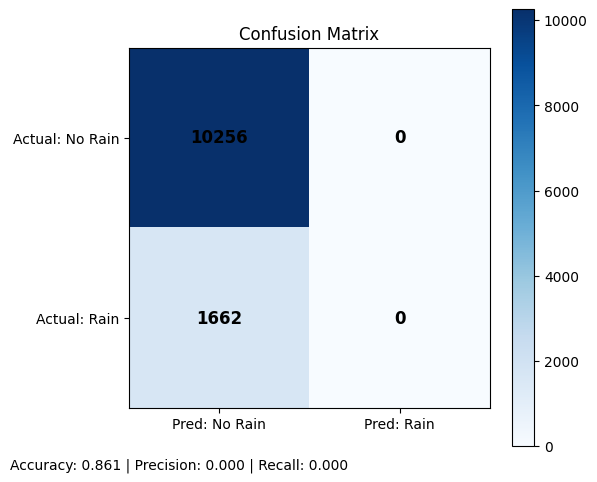

In [ ]:
with torch.no_grad():
  probs = model(test_in)
  pred_binary = (probs > 0.5).int() # Q: Why choose 0.5 here?

actual_binary = (test_out > 0).int()

# compute metrics for confusion matrix
tn = ((pred_binary == 0) & (actual_binary == 0)).sum().item()
fp = ((pred_binary == 1) & (actual_binary == 0)).sum().item()
fn = ((pred_binary == 0) & (actual_binary == 1)).sum().item()
tp = ((pred_binary == 1) & (actual_binary == 1)).sum().item()

confusion_matrix = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, confusion_matrix[i, j],
                ha='center', va='center', fontsize=12, fontweight='bold')

plt.xticks([0, 1], ['Pred: No Rain', 'Pred: Rain'])
plt.yticks([0, 1], ['Actual: No Rain', 'Actual: Rain'])
plt.title('Confusion Matrix')

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

plt.figtext(0.02, 0.02, f'Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}')

plt.tight_layout()
plt.show()

## Exercise 1

Using the different features in the weather measurement data set, train an individual logistic regression model on each of the individual measurements:
- 'temperature_2m (°C)'
- 'precipitation (mm)'
- 'cloudcover (%)'
- 'windspeed_10m (km/h)'
- 'winddirection_10m (°)'

Plot the learning curve and predictions for the 5 different models each trained on a different set of measurements.
Calculate the binary rain prediction accuracy, precision and recall.

In [4]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Columns to use (single feature models)
features = [
    'temperature_2m (°C)',
    'precipitation (mm)',
    'cloudcover (%)',
    'windspeed_10m (km/h)',
    'winddirection_10m (°)'
]

# Read CSV and preprocess
df = pd.read_csv(dataset_path).dropna()
df['rain'] = (df['precipitation (mm)'] > 0).astype(int)  # binary target

# Normalize each feature individually
df[features] = (df[features] - df[features].mean()) / df[features].std()

results = {}

for feat in features:
    print(f"\n=== Training with feature: {feat} ===")
    x = torch.tensor(df[[feat]].values, dtype=torch.float32)
    y = torch.tensor(df['rain'].values, dtype=torch.float32).unsqueeze(1)

    # Train/test split
    n = x.shape[0]
    n_train = int(0.8 * n)
    x_train, x_test = x[:n_train], x[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]

    # Model: Logistic regression = Linear + Sigmoid
    model = torch.nn.Linear(1, 1)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    loss_fn = torch.nn.BCELoss()

    losses = []
    steps = 200

    for step in range(steps):
        model.train()
        optimizer.zero_grad()
        pred = torch.sigmoid(model(x_train))
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    # Evaluate
    model.eval()
    with torch.no_grad():
        test_probs = torch.sigmoid(model(x_test)).numpy().squeeze()
        test_preds = (test_probs >= 0.5).astype(int)
        y_true = y_test.numpy().squeeze()

        acc = accuracy_score(y_true, test_preds)
        prec = precision_score(y_true, test_preds)
        rec = recall_score(y_true, test_preds)

    # Save everything
    results[feat] = {
        'losses': losses,
        'preds': test_preds,
        'probs': test_probs,
        'y_true': y_true,
        'acc': acc,
        'prec': prec,
        'rec': rec
    }



=== Training with feature: temperature_2m (°C) ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Training with feature: precipitation (mm) ===

=== Training with feature: cloudcover (%) ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Training with feature: windspeed_10m (km/h) ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Training with feature: winddirection_10m (°) ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
## Your solution ##


## Optimization

While the model design and parameter space are important to be able to accurately learn a representative hypothesis to predict a given task, the method which we use for approximating the optimal values also play an important role in the final prediction accuracy and the stability of the model runs at different trials.

The gradient descent algorithm helps minimize a loss function by computing the gradients and using their values on the trainig samples to update the model parameters. For an exact computation, the original gradient descent algorithm iterates over the entire training set and evaluates the gradient of the loss function over these input values $x$ and correct output values $y$, then uses the value for the weight $w$ update as follows.

$$
  \textrm{Compute the gradient: } g_t = - \frac{1}{N}\sum_{n=1}^N \frac{y^nx^n}{1 + e^{y^nw^T(t)x^n}}
$$

$$
  \textrm{Update the weights: } w_{t+1} = w_t + \rho g_t
$$

Note that the sign of $g_t$ would change in the equation according to an increase or decrease in the loss.

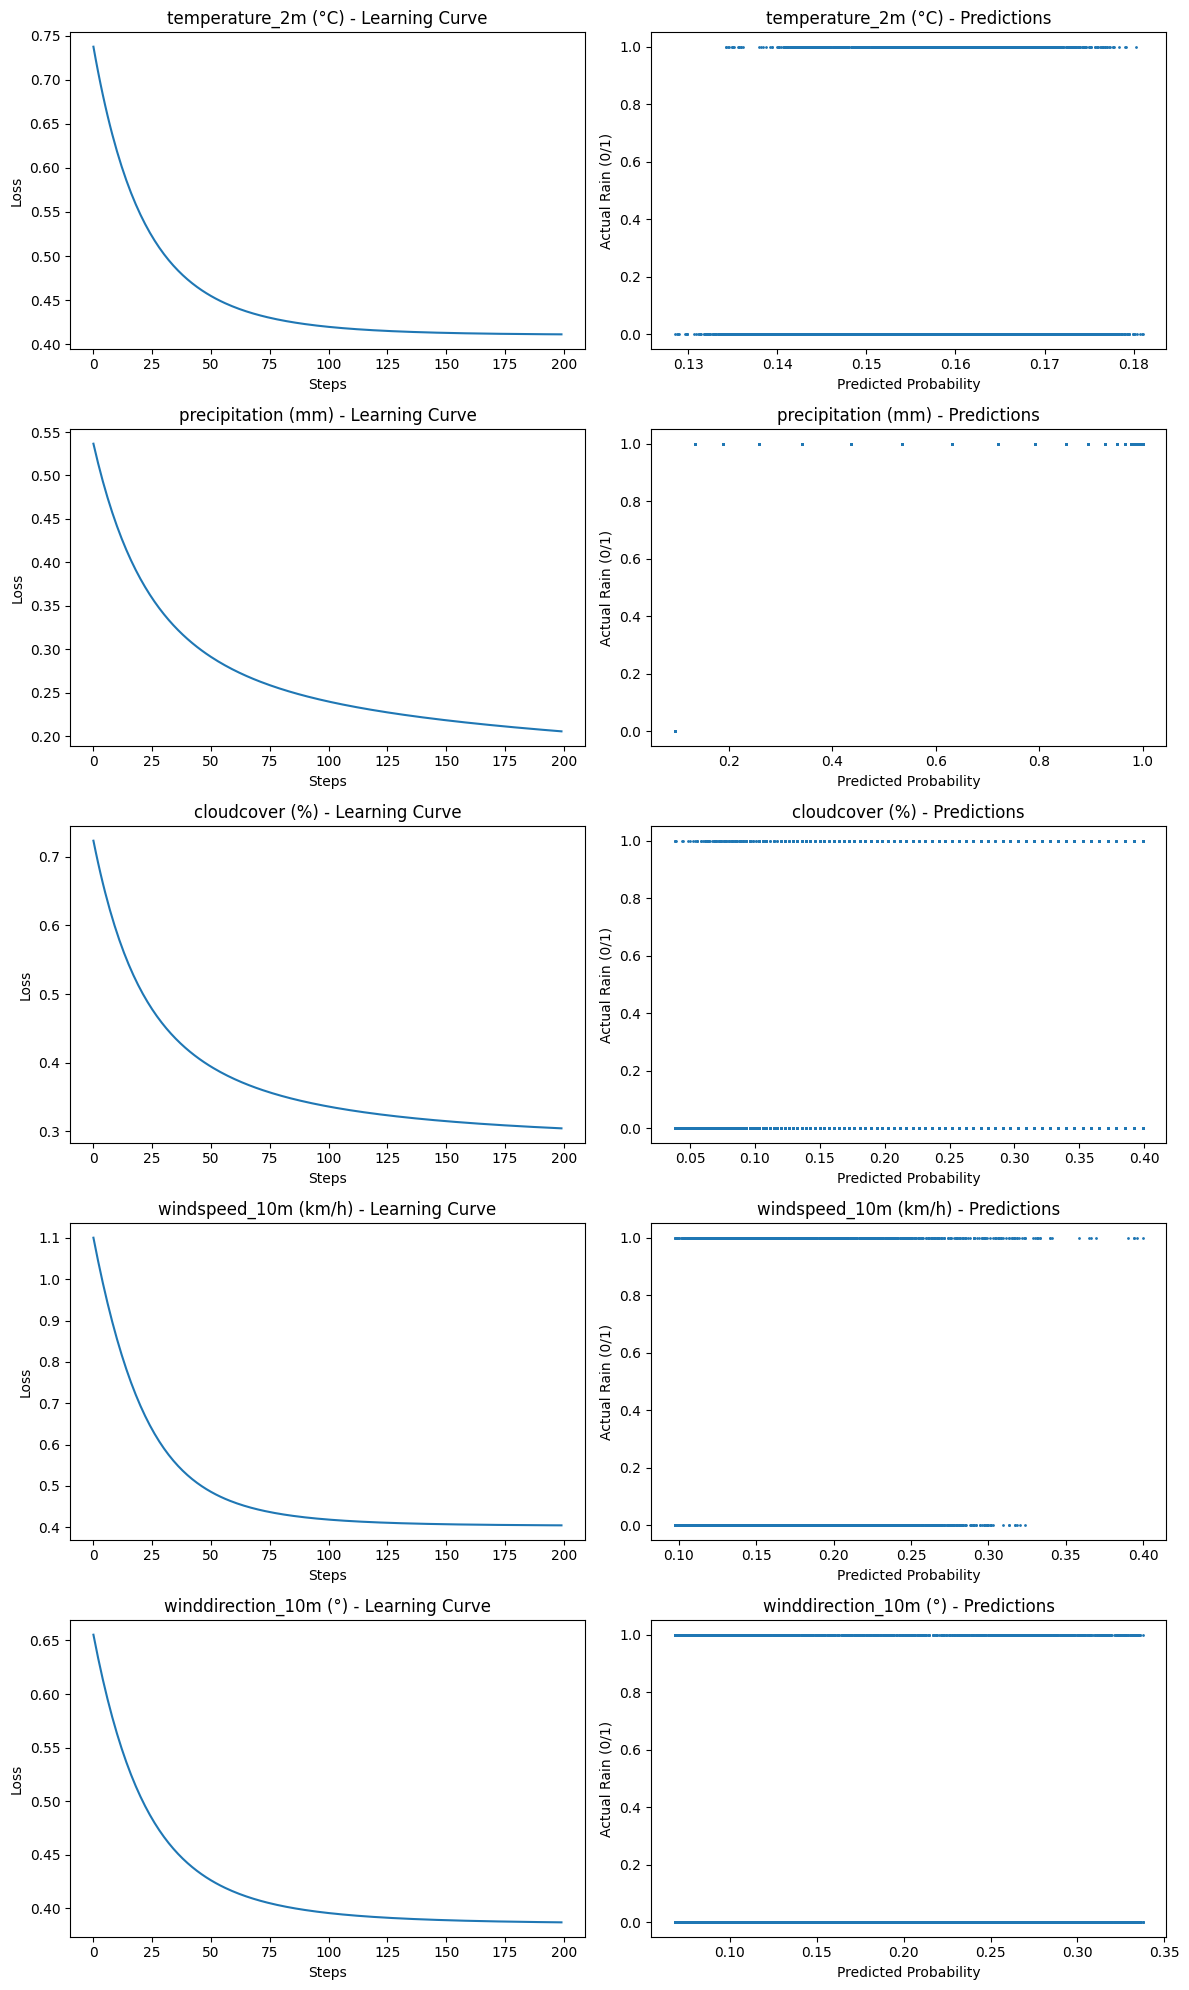

In [5]:
# Plot all 5 learning curves and scatterplots
fig, axs = plt.subplots(5, 2, figsize=(12, 20))

for i, feat in enumerate(features):
    axs[i, 0].plot(results[feat]['losses'])
    axs[i, 0].set_title(f'{feat} - Learning Curve')
    axs[i, 0].set_xlabel('Steps')
    axs[i, 0].set_ylabel('Loss')

    axs[i, 1].scatter(results[feat]['probs'], results[feat]['y_true'], s=1)
    axs[i, 1].set_title(f'{feat} - Predictions')
    axs[i, 1].set_xlabel('Predicted Probability')
    axs[i, 1].set_ylabel('Actual Rain (0/1)')

plt.tight_layout()
plt.show()


## Exercise 2

Implement the logistic regression model on the weather prediction data set. Instead of the PyTorch SGD optimizer, create a function which implements weight update using PyTorch autograd. Plot the learning curve and predictions. Calculate the prediction accuracy, precision and recall.

In [ ]:
## Your solution ##
from torch import autograd

def update_parameters(train_in, train_out):
  ## Update to do parameter update with gradient descent
  ##
  ##
  ##
  return train_in, train_out, test_in, test_out



In [6]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

# Use only one feature for now (you can loop through others later)
FEATURE = 'cloudcover (%)'  # Change this to test other features

# Load and preprocess
df = pd.read_csv(dataset_path).dropna()
df['rain'] = (df['precipitation (mm)'] > 0).astype(int)
df[FEATURE] = (df[FEATURE] - df[FEATURE].mean()) / df[FEATURE].std()

x = torch.tensor(df[[FEATURE]].values, dtype=torch.float32)
y = torch.tensor(df['rain'].values, dtype=torch.float32).unsqueeze(1)

# Split
n = x.shape[0]
n_train = int(0.8 * n)
x_train, x_test = x[:n_train], x[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# Parameters (weights and bias)
w = torch.randn((1, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.1
steps = 200
losses = []

# Training loop
for step in range(steps):
    # Forward pass: sigmoid(wx + b)
    logits = x_train @ w + b
    probs = torch.sigmoid(logits)

    # Binary cross-entropy
    loss = F.binary_cross_entropy(probs, y_train)
    losses.append(loss.item())

    # Backprop
    loss.backward()

    # Gradient descent step
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

        # Zero gradients manually
        w.grad.zero_()
        b.grad.zero_()

# Evaluation
with torch.no_grad():
    probs_test = torch.sigmoid(x_test @ w + b).squeeze().numpy()
    preds_test = (probs_test >= 0.5).astype(int)
    y_true = y_test.squeeze().numpy()

acc = accuracy_score(y_true, preds_test)
prec = precision_score(y_true, preds_test)
rec = recall_score(y_true, preds_test)

print(f"\n[Feature: {FEATURE}]")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")



[Feature: cloudcover (%)]
Accuracy:  0.8497
Precision: 0.0000
Recall:    0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


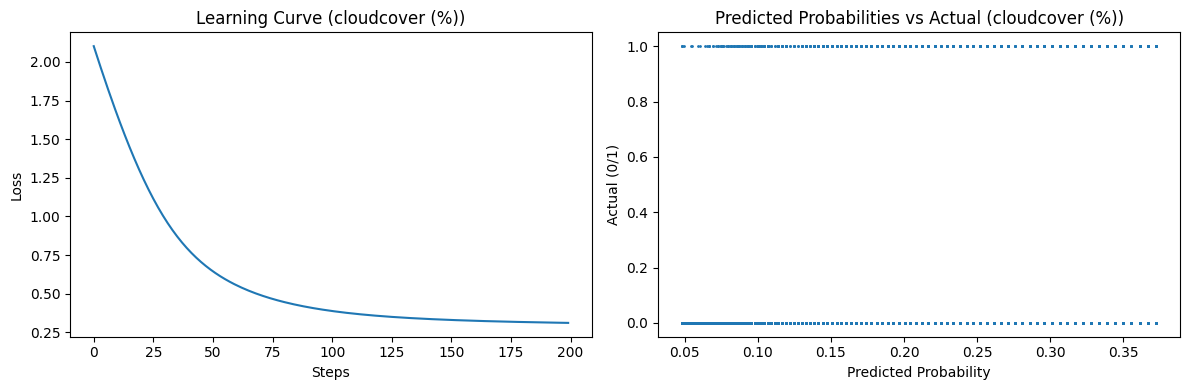

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title(f'Learning Curve ({FEATURE})')
plt.xlabel('Steps')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.scatter(probs_test, y_true, s=1)
plt.title(f'Predicted Probabilities vs Actual ({FEATURE})')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual (0/1)')

plt.tight_layout()
plt.show()


In [8]:
rain_ratio = df['rain'].mean()
print(f"Percentage of rainy days: {rain_ratio:.2%}")


Percentage of rainy days: 14.47%


In [9]:
thresholds = [0.3, 0.5, 0.7]
for t in thresholds:
    preds = (probs_test >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(f"  Accuracy : {accuracy_score(y_true, preds):.4f}")
    print(f"  Precision: {precision_score(y_true, preds):.4f}")
    print(f"  Recall   : {recall_score(y_true, preds):.4f}")



Threshold: 0.3
  Accuracy : 0.8295
  Precision: 0.4553
  Recall   : 0.6845

Threshold: 0.5
  Accuracy : 0.8497
  Precision: 0.0000
  Recall   : 0.0000

Threshold: 0.7
  Accuracy : 0.8497
  Precision: 0.0000
  Recall   : 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Exercise 3 (Optional)

Try to put together some of the things we have learned to see if you can come up with an even better model! Think: how could we deal with the class imbalance problem? Is there a different threshold we can choose for classification? Then, how can we possibly combine the models to obtain better rainfall predictions?


Custom threshold tuning (e.g., 0.3 instead of 0.5)

Check class balance in the dataset

Weighted loss or oversampling (optional for advanced)

Combine models (e.g., ensemble or voting)